## Timing Comparison Plots for Transition Matrix Creation.

This notebook is designed to compare the transition matrix creation between https://arxiv.org/abs/2110.08273 and the new state-to-state method.

In [90]:
import csv
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import curve_fit
from decimal import Decimal


## \phi^2 Timing

--- Benchmark Params ---
mQ = 1, mV = 1, r = 1.0
--- New Method Params ---
mQ = 1, mV = 1, r = 1


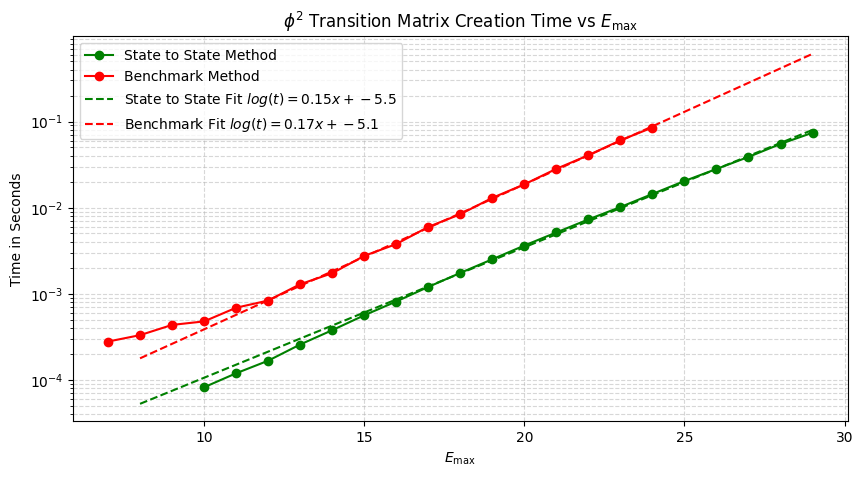

In [134]:
# 1. Parameters for the plot

emax_list = range(7,30) #Test Range of E_max.

# 2. Importing comparison timings. 

#This file is produced from the code 'phi4_truncation.ipynb' and imported here.
benchmark_filename = "phi2_benchmark_results.csv"
execution_times_benchmark = []
with open(benchmark_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Params ---')
    print(''.join(next(reader)))
            
    # Skips header for e_max list.
    next(reader) 
    emax_list_benchmark = list(map(float,next(reader))) #Saves e_max list and converts to float.
        
    next(reader) # Skips header for timing benchmark
    
    for row in reader:
        # Add data to execution_times_benchmark list.
        execution_times_benchmark.append(float(row[1])) # Convert time back to float

#This file is produced from the code 'CoinHamming_phi2HT.ipynb' and imported here.
statestate_filename = "phi2_statetostate_results.csv"
execution_times_statestate = []
with open(statestate_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for new method. Confirm that these are the same in-use here!
    print('--- New Method Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_list_statestate = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader) #Skips Header.
    for row in reader:
        # Adds data to execution_times_statestate list.
        execution_times_statestate.append(float(row[1])) # Convert time back to float


# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

# Raw Data Plot Initially
ax1.plot(emax_list_statestate, execution_times_statestate, marker='o', linestyle='-', color='g', label='State to State Method')
ax1.plot(emax_list_benchmark, execution_times_benchmark, marker ='o', linestyle='-', color='r', label='Benchmark Method')

# 4. First degree polynomial fit to the timing data.
startix = 5 # Starting index for the polynomial fit in case it is noisy.
coef_statestate = (np.polyfit(emax_list_statestate[startix:], np.log10(execution_times_statestate)[startix:], 1))
coef_bench = (np.polyfit(emax_list_benchmark[startix:], np.log10(execution_times_benchmark)[startix:], 1))

poly_statestate = np.poly1d(coef_statestate)
poly_bench = np.poly1d(coef_bench)
xs = np.linspace(emax_list[1],emax_list[-1])

# Plots the polynomial fit.
ax1.plot(xs, 10**poly_statestate(xs), linestyle='--', color='g', label=f'State to State Fit $log(t)={coef_statestate[0]:.2f}x+{coef_statestate[1]:.1f}$')
ax1.plot(xs, 10**poly_bench(xs), linestyle='--', color='r', label=f'Benchmark Fit $log(t)={coef_bench[0]:.2f}x+{coef_bench[1]:.1f}$')
ax1.legend()



plt.title(r'$\phi^2$ Transition Matrix Creation Time vs $E_\text{max}$')
plt.show()


## 2. \phi^4 Timing:

--- Benchmark Params ---
mQ = 1, mV = 1, r = 1.0
--- New Method Params ---
mQ = 1, mV = 1, r = 1
--- n log n fit ---
a1 : 0.0000, a2 : 3.5713
y = 3.03E-6 * n ** 3.5713 log(n) + 0.0180


/var/folders/mn/tf06d9kn2d375gz4l9ykzljm0000gn/T/ipykernel_2766/1443891735.py:73: RuntimeWarning: invalid value encountered in log
  return np.log(a1 * n**a2 * np.log(n)+ c)


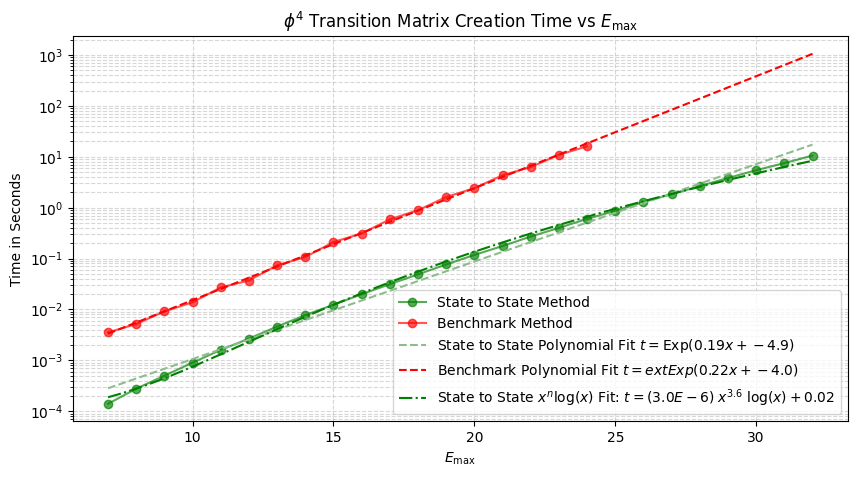

In [132]:
# 1. Parameters for the plot

emax_list = range(7,33) #Test Range of E_max.

# 2. Importing comparison timings. 

#This file is produced from the code 'phi4_truncation.ipynb' and imported here.
benchmark_filename = "phi4_benchmark_results.csv"
execution_times_benchmark = []
with open(benchmark_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Params ---')
    print(''.join(next(reader)))
            
    # Skips header for e_max list.
    next(reader) 
    emax_list_benchmark = list(map(float,next(reader))) #Saves e_max list and converts to float.
        
    next(reader) # Skips header for timing benchmark
    
    for row in reader:
        # Add data to execution_times_benchmark list.
        execution_times_benchmark.append(float(row[1])) # Convert time back to float

#This file is produced from the code 'faster_phi4.ipynb' and imported here.
statestate_filename = "phi4_statetostate_results.csv"
execution_times_statestate = []
with open(statestate_filename, mode="r") as file:
    reader = csv.reader(file)
    # Prints Hamiltonian parameters for new method. Confirm that these are the same in-use here!
    print('--- New Method Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_list_statestate = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader) #Skips Header.
    for row in reader:
        # Adds data to execution_times_statestate list.
        execution_times_statestate.append(float(row[1])) # Convert time back to float


# 3. Plot the results
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Time in Seconds')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

# Raw Data Plot Initially
ax1.plot(emax_list_statestate, execution_times_statestate, marker='o', linestyle='-', color='g', alpha=0.66, label='State to State Method')
ax1.plot(emax_list_benchmark, execution_times_benchmark, marker ='o', linestyle='-', color='r', alpha=0.66, label='Benchmark Method')

# 4. First degree polynomial fit to the timing data.
startix = 0 # Starting index for the polynomial fit in case it is noisy.
coef_statestate = (np.polyfit(emax_list_statestate[startix:], np.log10(execution_times_statestate)[startix:], 1))
coef_bench = (np.polyfit(emax_list_benchmark[startix:], np.log10(execution_times_benchmark)[startix:], 1))

poly_statestate = np.poly1d(coef_statestate)
poly_bench = np.poly1d(coef_bench)
xs = np.linspace(emax_list[0],emax_list[-1])

# Plots the polynomial fit.
ax1.plot(xs, 10**poly_statestate(xs), linestyle='--', color='darkseagreen', label=rf'State to State Polynomial Fit $t=\text{{Exp}}({coef_statestate[0]:.2f}x+{coef_statestate[1]:.1f})$')
ax1.plot(xs, 10**poly_bench(xs), linestyle='--', color='r', label=f'Benchmark Polynomial Fit $t=\text{{Exp}}({coef_bench[0]:.2f}x+{coef_bench[1]:.1f})$')


# An nlog(n) fit to the data.
def n_log_n_with_intercept(n, a1, a2, c):
    return np.log(a1 * n**a2 * np.log(n)+ c)

# 2. Perform the curve fit
# popt will contain the optimized parameters (in this case, just [c])
popt, pcov = curve_fit(n_log_n_with_intercept, emax_list_statestate[startix:], np.log10(execution_times_statestate)[startix:])
a1, a2, c = popt

print("--- n log n fit ---")
print(f"a1 : {a1:.4f}, a2 : {a2:.4f}")
print(f"y = {Decimal(a1):.2E} * n ** {a2:.4f} log(n) + {c:.4f}")

# 3. Generate smooth points for plotting the trendline
n_line = np.linspace(min(emax_list_statestate[startix:]), max(emax_list_statestate[startix:]), 500)
y_line = n_log_n_with_intercept(n_line, a1, a2, c)

plt.plot(n_line, 10**y_line, linestyle='-.', color='g', label=rf'State to State $x^n \text{{log}}(x)$ Fit: $t = ({Decimal(a1):.1E})\; x^{{{a2:.1f}}}\; \text{{log}}(x) + {c:.2f}$')

ax1.legend()
plt.title(r'$\phi^4$ Transition Matrix Creation Time vs $E_\text{max}$')
plt.show()
